# Caso práctico: capacidad de red de AndesTel

## Contexto empresarial

AndesTel Telecom S.A.C. brinda servicios de Internet residencial mediante redes FTTH y HFC en distintas zonas de Lima y Callao.

El área comercial quiere lanzar una campaña para captar nuevos clientes. Sin embargo, el área de Operaciones advierte que algunas zonas podrían encontrarse cerca del límite de capacidad durante las horas de mayor tráfico.

La gerencia solicita al equipo de Analítica determinar:

**¿En qué zonas existe capacidad suficiente para continuar vendiendo nuevos servicios y en qué zonas es necesario ampliar la infraestructura antes de captar más clientes?**

## Dataset

Zonas: Representa la infraestructura disponible (zonas.csv).

| Campo              | Descripción                   |
| ------------------ | ----------------------------- |
| `zona_id`          | Código de zona                |
| `zona`             | Nombre                        |
| `region`           | Sector geográfico             |
| `tecnologia`       | FTTH / HFC                    |
| `capacidad_mbps`   | Capacidad total del enlace    |
| `limite_operacion` | Porcentaje máximo recomendado |

Clientes: Contiene el parque comercial (clientes.csv).

| Campo        | Descripción               |
| ------------ | ------------------------- |
| `cliente_id` | Identificador             |
| `zona_id`    | Zona donde está conectado |
| `plan_mbps`  | Velocidad contratada      |
| `estado`     | ACTIVO / SUSPENDIDO       |
| `fecha_alta` | Fecha de alta             |


Trafico de red: Contendrá mediciones horarias durante un mes (trafico_red.csv).

| Campo                  | Descripción       |
| ---------------------- | ----------------- |
| `timestamp`            | Fecha y hora      |
| `zona_id`              | Zona              |
| `trafico_down_mbps`    | Tráfico download  |
| `trafico_up_mbps`      | Tráfico upload    |
| `latencia_ms`          | Latencia promedio |
| `perdida_paquetes_pct` | Packet loss       |


## Supuesto

### Política de capacidad de AndesTel

Para efectos del caso, la empresa establece que no debe planificar ventas utilizando el 100% de la capacidad física. El máximo recomendado será: **80%**

| Utilización P95 | Estado        | Decisión                          |
| --------------: | ------------- | --------------------------------- |
|           ≤ 65% | 🟢 Saludable  | Se pueden captar nuevos clientes  |
|     >65% y ≤80% | 🟡 Preventivo | Venta controlada                  |
|            >80% | 🔴 Crítico    | No vender hasta ampliar capacidad |


Para el ejercicio utilizaremos el percentil 95 del tráfico horario:

**El P95 representa un nivel de tráfico elevado que se alcanza o supera aproximadamente durante el 5% de las mediciones.**

En una operación real dependería de la arquitectura, redundancia, SLA, tecnología, tráfico upstream/downstream y criterios de ingeniería del operador.

In [14]:
## 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
## 2. Cargar los datos del archivo CSV
df_clientes = pd.read_csv('./casos/clientes.csv')
df_zonas = pd.read_csv('./casos/zonas.csv')
df_trafico = pd.read_csv('./casos/trafico_red.csv')

## Mostrar las primeras filas de cada DataFrame
print("Datos de Clientes:")
display(df_clientes.head())

print("\nDatos de Zonas:")
display(df_zonas.head())

print("\nDatos de Tráfico de Red:")
display(df_trafico.head())

Datos de Clientes:


,cliente_id,zona_id,plan_mbps,estado,fecha_alta
0,C000001,Z001,300,ACTIVO,2025-01-24
1,C000002,Z001,300,ACTIVO,2026-02-11
2,C000003,Z001,600,Activo,2025-10-07
3,C000004,Z001,100,ACTIVO,2025-12-08
4,C000005,Z001,200,activo,2025-12-04



Datos de Zonas:


,zona_id,zona,region,tecnologia,capacidad_mbps,limite_operacion
0,Z001,Miraflores,Lima Centro,FTTH,10000,0.8
1,Z002,San Isidro,Lima Centro,FTTH,8000,0.8
2,Z003,Surco,Lima Sur,FTTH,12000,0.8
3,Z004,San Miguel,Lima Oeste,HFC,6000,0.8
4,Z005,Los Olivos,Lima Norte,HFC,7000,0.8



Datos de Tráfico de Red:


,timestamp,zona_id,trafico_down_mbps,trafico_up_mbps,latencia_ms,perdida_paquetes_pct
0,2026-08-01 00:00:00,Z001,2273.31,271.64,13.99,0.082
1,2026-08-01 01:00:00,Z001,1966.15,191.25,13.54,0.055
2,2026-08-01 02:00:00,Z001,2171.61,306.33,13.91,0.040
3,2026-08-01 03:00:00,Z001,2116.18,308.24,15.84,0.098
4,2026-08-01 04:00:00,Z001,2040.20,254.21,14.46,0.081


In [16]:
## 3. Visualizar el tamaño de los dataframes
print(f"Tamaño del DataFrame de Clientes: {df_clientes.shape}")
print(f"Tamaño del DataFrame de Zonas: {df_zonas.shape}")
print(f"Tamaño del DataFrame de Tráfico de Red: {df_trafico.shape}")

Tamaño del DataFrame de Clientes: (8000, 5)
Tamaño del DataFrame de Zonas: (8, 6)
Tamaño del DataFrame de Tráfico de Red: (5960, 6)


In [17]:
## 4. Verificando valores nulos
print("Valores nulos en Clientes:")
print(df_clientes.isnull().sum().sort_values(ascending=False))

print("\nValores nulos en Zonas:")
print(df_zonas.isnull().sum().sort_values(ascending=False))

print("\nValores nulos en Tráfico de Red:")
print(df_trafico.isnull().sum().sort_values(ascending=False))

Valores nulos en Clientes:
cliente_id    0
zona_id       0
plan_mbps     0
estado        0
fecha_alta    0
dtype: int64

Valores nulos en Zonas:
zona_id             0
zona                0
region              0
tecnologia          0
capacidad_mbps      0
limite_operacion    0
dtype: int64

Valores nulos en Tráfico de Red:
trafico_down_mbps       12
timestamp                0
zona_id                  0
trafico_up_mbps          0
latencia_ms              0
perdida_paquetes_pct     0
dtype: int64


In [18]:
## 5. Eliminar nulos de los DataFrames
df_clientes = df_clientes.dropna()
df_zonas = df_zonas.dropna()
df_trafico = df_trafico.dropna()

## Volver a mostrar el tamaño de los dataframes después de eliminar nulos
print("\nDespués de eliminar nulos:")
print(f"Tamaño del DataFrame de Clientes: {df_clientes.shape}")
print(f"Tamaño del DataFrame de Zonas: {df_zonas.shape}")
print(f"Tamaño del DataFrame de Tráfico de Red: {df_trafico.shape}")


Después de eliminar nulos:
Tamaño del DataFrame de Clientes: (8000, 5)
Tamaño del DataFrame de Zonas: (8, 6)
Tamaño del DataFrame de Tráfico de Red: (5948, 6)


In [19]:
## 6. Revisar datos duplicados en los DataFrames
print("\nDatos duplicados en Clientes:")
print(df_clientes[df_clientes.duplicated()])
print("\nDatos duplicados en Zonas:")
print(df_zonas[df_zonas.duplicated()])
print("\nDatos duplicados en Tráfico de Red:")
print(df_trafico[df_trafico.duplicated()])


Datos duplicados en Clientes:
Empty DataFrame
Columns: [cliente_id, zona_id, plan_mbps, estado, fecha_alta]
Index: []

Datos duplicados en Zonas:
Empty DataFrame
Columns: [zona_id, zona, region, tecnologia, capacidad_mbps, limite_operacion]
Index: []

Datos duplicados en Tráfico de Red:
                timestamp zona_id  trafico_down_mbps  trafico_up_mbps  \
5952  2026-08-14 07:00:00    Z006            2071.44           268.90   
5953  2026-08-22 23:00:00    Z006            5175.91           723.29   
5954  2026-08-20 22:00:00    Z003            8792.67          1106.45   
5955  2026-08-13 13:00:00    Z007            1675.66           152.09   
5956  2026-08-27 06:00:00    Z002            2049.93           256.96   
5957  2026-08-31 08:00:00    Z007            1703.69           218.80   
5958  2026-08-17 22:00:00    Z003            8570.74          1501.92   
5959  2026-08-11 00:00:00    Z006            2236.50           277.10   

      latencia_ms  perdida_paquetes_pct  
5952       

In [20]:
## 7. Eliminar duplicados de los DataFrames
df_clientes = df_clientes.drop_duplicates()
df_zonas = df_zonas.drop_duplicates()
df_trafico = df_trafico.drop_duplicates()

## Volver a mostrar el tamaño de los dataframes después de eliminar duplicados
print("\nDespués de eliminar duplicados:")
print(f"Tamaño del DataFrame de Clientes: {df_clientes.shape}")
print(f"Tamaño del DataFrame de Zonas: {df_zonas.shape}")
print(f"Tamaño del DataFrame de Tráfico de Red: {df_trafico.shape}")


Después de eliminar duplicados:
Tamaño del DataFrame de Clientes: (8000, 5)
Tamaño del DataFrame de Zonas: (8, 6)
Tamaño del DataFrame de Tráfico de Red: (5940, 6)


In [21]:
## 8. Normalizar todos los datos categóricos a mayusculas en todos los dataframes
categorical_columns_clientes = df_clientes.select_dtypes(include=['object']).columns
categorical_columns_zonas = df_zonas.select_dtypes(include=['object']).columns
categorical_columns_trafico = df_trafico.select_dtypes(include=['object']).columns

df_clientes[categorical_columns_clientes] = df_clientes[categorical_columns_clientes].apply(lambda x: x.str.upper().str.strip())
df_zonas[categorical_columns_zonas] = df_zonas[categorical_columns_zonas].apply(lambda x: x.str.upper().str.strip())
df_trafico[categorical_columns_trafico] = df_trafico[categorical_columns_trafico].apply(lambda x: x.str.upper().str.strip())


C:\Users\Marlon\AppData\Local\Temp\ipykernel_21296\2687182266.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns_clientes = df_clientes.select_dtypes(include=['object']).columns
C:\Users\Marlon\AppData\Local\Temp\ipykernel_21296\2687182266.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pa

In [22]:
## Mostrar las primeras filas de cada DataFrame despues de normalizar los datos categóricos
print("Datos de Clientes:")
display(df_clientes.head())

print("\nDatos de Zonas:")
display(df_zonas.head())

print("\nDatos de Tráfico de Red:")
display(df_trafico.head())

Datos de Clientes:


,cliente_id,zona_id,plan_mbps,estado,fecha_alta
0,C000001,Z001,300,ACTIVO,2025-01-24
1,C000002,Z001,300,ACTIVO,2026-02-11
2,C000003,Z001,600,ACTIVO,2025-10-07
3,C000004,Z001,100,ACTIVO,2025-12-08
4,C000005,Z001,200,ACTIVO,2025-12-04



Datos de Zonas:


,zona_id,zona,region,tecnologia,capacidad_mbps,limite_operacion
0,Z001,MIRAFLORES,LIMA CENTRO,FTTH,10000,0.8
1,Z002,SAN ISIDRO,LIMA CENTRO,FTTH,8000,0.8
2,Z003,SURCO,LIMA SUR,FTTH,12000,0.8
3,Z004,SAN MIGUEL,LIMA OESTE,HFC,6000,0.8
4,Z005,LOS OLIVOS,LIMA NORTE,HFC,7000,0.8



Datos de Tráfico de Red:


,timestamp,zona_id,trafico_down_mbps,trafico_up_mbps,latencia_ms,perdida_paquetes_pct
0,2026-08-01 00:00:00,Z001,2273.31,271.64,13.99,0.082
1,2026-08-01 01:00:00,Z001,1966.15,191.25,13.54,0.055
2,2026-08-01 02:00:00,Z001,2171.61,306.33,13.91,0.040
3,2026-08-01 03:00:00,Z001,2116.18,308.24,15.84,0.098
4,2026-08-01 04:00:00,Z001,2040.20,254.21,14.46,0.081


In [23]:
## 9. Convertir a fechas los campos feca_alta de clientes y timestamp de trafico_red
df_clientes['fecha_alta'] = pd.to_datetime(df_clientes['fecha_alta'], errors='coerce', format='%Y-%m-%d')
df_trafico['timestamp'] = pd.to_datetime(df_trafico['timestamp'], errors='coerce', format='%Y-%m-%d %H:%M:%S')

In [ ]:
## 10. Eliminar datos incoherentes
df_clientes = df_clientes[df_clientes['plan_mbps'] > 0]
df_zonas = df_zonas[df_zonas['capacidad_mbps'] > 0]
df_zonas = df_zonas[(df_zonas['limite_operacion'] >= 0) & (df_zonas['limite_operacion'] <= 1)]
df_trafico = df_trafico[df_trafico['trafico_down_mbps'] >= 0]
df_trafico = df_trafico[df_trafico['trafico_up_mbps'] >= 0]
df_trafico = df_trafico[df_trafico['latencia_ms'] >= 0]

In [26]:
## 11. Mostrar cantidad de clientes por zona
clientes_por_zona = df_clientes.groupby('zona_id').size().reset_index(name='cantidad_clientes')
print("\nCantidad de clientes por zona:")
display(clientes_por_zona)


Cantidad de clientes por zona:


,zona_id,cantidad_clientes
0,Z001,1200
1,Z002,900
2,Z003,1600
3,Z004,850
4,Z005,1000
5,Z006,1100
6,Z007,650
7,Z008,700


In [27]:
## 12. Mostrar la cantidad de clientes por zona y plan contrado (pivot table)
clientes_por_zona_y_plan = df_clientes.pivot_table(index='zona_id', columns='plan_mbps', values='cliente_id', aggfunc='count', fill_value=0)
print("\nCantidad de clientes por zona y plan contratado:")
display(clientes_por_zona_y_plan)


Cantidad de clientes por zona y plan contratado:


plan_mbps,100,200,300,500,600
zona_id,,,,,
Z001,297,344,301,200,58
Z002,236,285,199,137,43
Z003,386,487,401,232,94
Z004,210,260,212,124,44
Z005,250,310,251,149,40
Z006,258,299,301,186,56
Z007,152,175,175,118,30
Z008,170,204,186,109,31


In [28]:
## 13. Crear las columnas fecha y hora del timestamp en el DataFrame de tráfico de red
df_trafico['fecha'] = df_trafico['timestamp'].dt.date
df_trafico['hora'] = df_trafico['timestamp'].dt.time

In [29]:
## 14. Mostrar el tráfico de red de bajada (trafico_down_mbps) promedio por hora del día
trafico_promedio_por_hora = df_trafico.groupby('hora')['trafico_down_mbps'].mean().reset_index(name='promedio_trafico_down_mbps')
print("\nTráfico de red de bajada promedio por hora del día:")
display(trafico_promedio_por_hora)


Tráfico de red de bajada promedio por hora del día:


,hora,promedio_trafico_down_mbps
0,00:00:00,2149.247449
1,01:00:00,2141.218871
2,02:00:00,2159.662823
3,03:00:00,2163.235344
4,04:00:00,2157.430000
5,05:00:00,2151.730976
6,06:00:00,2133.836371
7,07:00:00,2152.717773
8,08:00:00,2139.747172
9,09:00:00,2145.888065


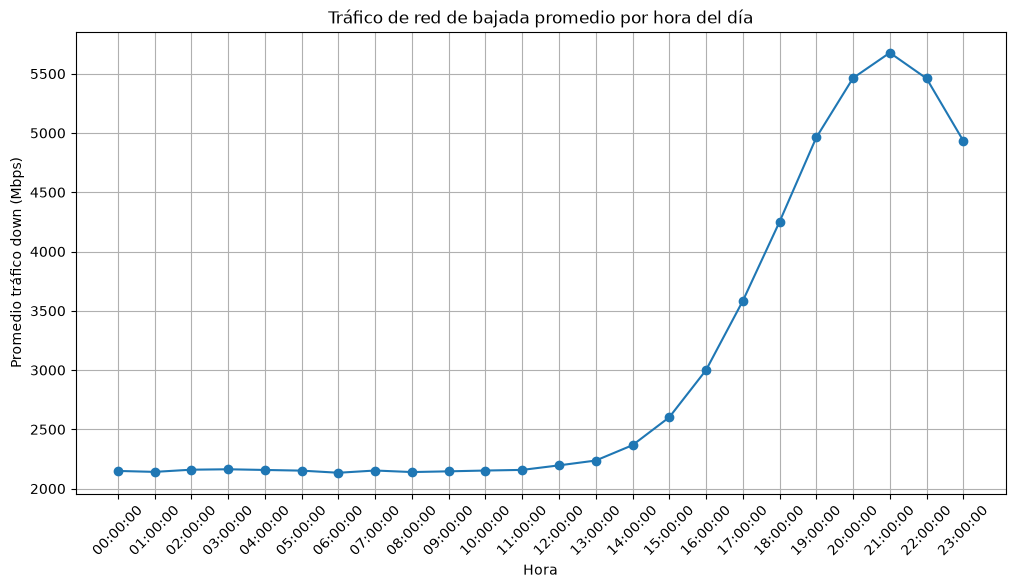

In [32]:
## Graficar el tráfico de red de bajada promedio por hora del día
plt.figure(figsize=(12, 6))
plt.plot(trafico_promedio_por_hora['hora'].astype(str), trafico_promedio_por_hora['promedio_trafico_down_mbps'], marker='o')
plt.xticks(rotation=45)
plt.title('Tráfico de red de bajada promedio por hora del día')
plt.xlabel('Hora')
plt.ylabel('Promedio tráfico down (Mbps)')
plt.grid(True)
plt.show()

In [33]:
## 15. Mostrar el tráfico de red de bajada (trafico_down_mbps) promedio por hora del día por zona (pivot table)
trafico_promedio_por_hora_y_zona = df_trafico.pivot_table(index='hora', columns='zona_id', values='trafico_down_mbps', aggfunc='mean', fill_value=0)
print("\nTráfico de red de bajada promedio por hora del día por zona:")
display(trafico_promedio_por_hora_y_zona)


Tráfico de red de bajada promedio por hora del día por zona:


zona_id,Z001,Z002,Z003,Z004,Z005,Z006,Z007,Z008
hora,,,,,,,,
00:00:00,2127.785484,2176.721000,3377.524839,1880.702581,2342.844194,2256.267742,1736.474194,1296.545806
01:00:00,2121.204194,2144.103548,3381.609677,1894.892258,2314.016774,2266.335484,1716.051935,1291.537097
02:00:00,2130.117097,2178.732903,3475.292581,1895.518065,2321.994516,2265.772581,1737.253226,1272.621613
03:00:00,2147.971613,2181.183548,3391.829677,1905.376774,2345.462581,2240.760968,1767.087742,1298.309000
04:00:00,2127.863871,2181.296774,3420.379355,1895.536129,2342.645161,2253.597419,1739.595161,1298.526129
05:00:00,2118.696452,2150.070645,3395.091290,1930.508333,2322.439333,2253.719677,1740.777742,1300.914839
06:00:00,2116.820323,2139.276452,3334.122581,1894.654194,2318.111290,2225.456129,1748.236452,1294.013548
07:00:00,2122.356452,2145.609032,3419.201935,1879.820968,2343.385806,2257.867097,1744.559000,1295.775484
08:00:00,2137.198621,2155.748065,3376.789310,1916.200000,2343.355161,2239.113871,1753.413226,1275.803871


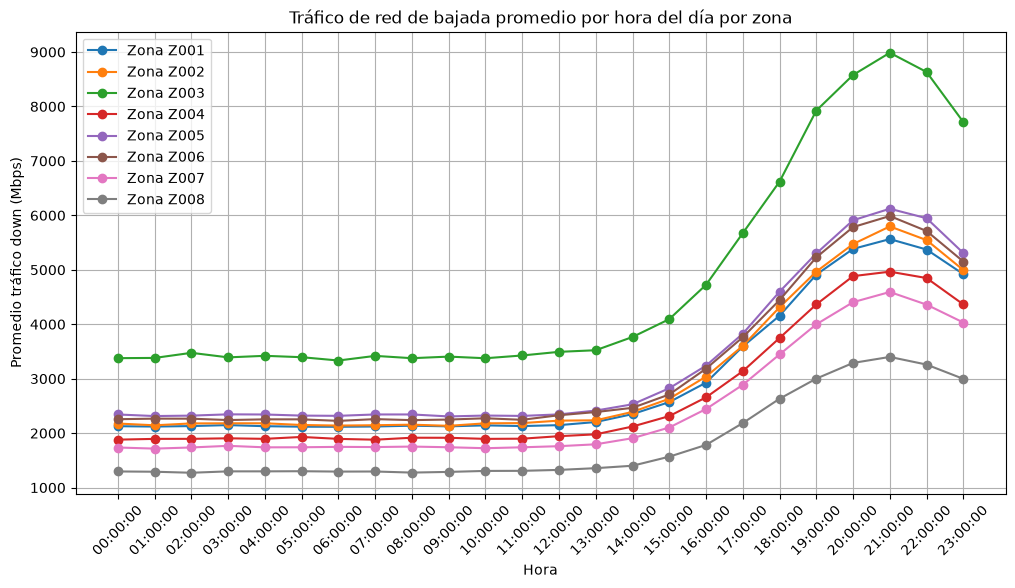

In [35]:
## 16. Mostrar el tráfico de red de bajada (trafico_down_mbps) promedio por hora del día por zona (gráfico)
plt.figure(figsize=(12, 6))
for zona in trafico_promedio_por_hora_y_zona.columns:
    plt.plot(trafico_promedio_por_hora_y_zona.index.astype(str), trafico_promedio_por_hora_y_zona[zona], marker='o', label=f'Zona {zona}')
plt.title('Tráfico de red de bajada promedio por hora del día por zona')
plt.xticks(rotation=45)
plt.xlabel('Hora')
plt.ylabel('Promedio tráfico down (Mbps)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
## 17. Agrupar el trafico de red por zona y calcular el trafico promedio de bajada, el maximo trafico de bajada,
# el percentil 95 del trafico de bajada, la latencia promedio y la perdida de paquetes promedio
trafico_agrupado_por_zona = df_trafico.groupby('zona_id').agg(
    promedio_trafico_down_mbps=('trafico_down_mbps', 'mean'),
    maximo_trafico_down_mbps=('trafico_down_mbps', 'max'),
    percentil_95_trafico_down_mbps=('trafico_down_mbps', lambda x: x.quantile(0.95)),
    promedio_latencia_ms=('latencia_ms', 'mean'),
    promedio_perdida_paquetes=('perdida_paquetes_pct', 'mean')
).reset_index()
display(trafico_agrupado_por_zona)

,zona_id,promedio_trafico_down_mbps,maximo_trafico_down_mbps,percentil_95_trafico_down_mbps,promedio_latencia_ms,promedio_perdida_paquetes
0,Z001,2987.657143,6363.54,5495.0405,14.035957,0.080532
1,Z002,3045.166622,6584.10,5667.7540,14.029027,0.081731
2,Z003,4775.017574,9744.64,8889.7000,14.071536,0.079106
3,Z004,2672.979785,5595.82,4965.5800,14.131359,0.082054
4,Z005,3261.278598,6907.62,6024.2375,14.227534,0.086111
5,Z006,3175.098035,6540.09,5894.1950,14.053351,0.080273
6,Z007,2444.389003,5049.02,4481.0195,14.209717,0.088061
7,Z008,1821.552682,3769.68,3344.7330,13.915849,0.080439


In [45]:
## 18. Calcular la capacidad utilizada por zona (trafico p95 / capacidad_mbps)
df_capacidad = trafico_agrupado_por_zona.merge(df_zonas[['zona_id', 'capacidad_mbps']], on='zona_id', how='left')
df_capacidad['capacidad_utilizada_pct'] = (df_capacidad['percentil_95_trafico_down_mbps'] / df_capacidad['capacidad_mbps']) * 100
display(df_capacidad)

,zona_id,promedio_trafico_down_mbps,maximo_trafico_down_mbps,percentil_95_trafico_down_mbps,promedio_latencia_ms,promedio_perdida_paquetes,capacidad_mbps,capacidad_utilizada_pct
0,Z001,2987.657143,6363.54,5495.0405,14.035957,0.080532,10000,54.950405
1,Z002,3045.166622,6584.10,5667.7540,14.029027,0.081731,8000,70.846925
2,Z003,4775.017574,9744.64,8889.7000,14.071536,0.079106,12000,74.080833
3,Z004,2672.979785,5595.82,4965.5800,14.131359,0.082054,6000,82.759667
4,Z005,3261.278598,6907.62,6024.2375,14.227534,0.086111,7000,86.060536
5,Z006,3175.098035,6540.09,5894.1950,14.053351,0.080273,9000,65.491056
6,Z007,2444.389003,5049.02,4481.0195,14.209717,0.088061,5000,89.620390
7,Z008,1821.552682,3769.68,3344.7330,13.915849,0.080439,7000,47.781900


In [49]:
## 19. Mostrar las zonas con su capacidad utilizada y la recomendacion de impulsar nuevos clientes de acuerdo con:
# ≤ 65% => 🟢 Saludable (Se pueden captar nuevos clientes)
# >65% y ≤80% => 🟡 Preventivo (Venta controlada)
# >80% => 🔴 Crítico  (No vender hasta ampliar capacidad)
def recomendar_venta(capacidad_utilizada):
    if capacidad_utilizada <= 65:
        return "🟢 Saludable (Se pueden captar nuevos clientes)"
    elif 65 < capacidad_utilizada <= 80:
        return "🟡 Preventivo (Venta controlada)"
    else:
        return "🔴 Crítico (No vender hasta ampliar capacidad)"

df_capacidad['capacidad_utilizada_pct'] = df_capacidad['capacidad_utilizada_pct'].apply(lambda x: round(x, 2))
df_capacidad['recomendacion_venta'] = df_capacidad['capacidad_utilizada_pct'].apply(recomendar_venta)
display(df_capacidad[['zona_id', 'capacidad_utilizada_pct', 'recomendacion_venta']])

,zona_id,capacidad_utilizada_pct,recomendacion_venta
0,Z001,54.95,🟢 Saludable (Se pueden captar nuevos clientes)
1,Z002,70.85,🟡 Preventivo (Venta controlada)
2,Z003,74.08,🟡 Preventivo (Venta controlada)
3,Z004,82.76,🔴 Crítico (No vender hasta ampliar capacidad)
4,Z005,86.06,🔴 Crítico (No vender hasta ampliar capacidad)
5,Z006,65.49,🟡 Preventivo (Venta controlada)
6,Z007,89.62,🔴 Crítico (No vender hasta ampliar capacidad)
7,Z008,47.78,🟢 Saludable (Se pueden captar nuevos clientes)
